In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.dates as mdates
import numpy as np


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load and prepare the data
file_path = '/content/drive/MyDrive/TIME SERIES ANALYSIS/Self_Collected_Pain_Levels.csv'
df = pd.read_csv(file_path, delimiter=';', parse_dates=['Timestamp'], index_col='Timestamp')

# Display formatted output
display(df.head())

print("\n=== BASIC INFO ===")
print(f"Time Range: {df.index.min()} to {df.index.max()}")
print(f"Total Entries: {len(df)}")
print("\nColumn Types:")
print(df.dtypes.to_string())  # Cleaner than info() for just dtypes

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0].to_string() or "No missing values found")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Pain_Level
Timestamp,
2025-05-28 09:00:00,9.0
2025-05-28 15:00:00,8.0
2025-05-28 21:00:00,8.5
2025-05-29 09:00:00,8.5
2025-05-29 15:00:00,7.5



=== BASIC INFO ===
Time Range: 2025-05-28 09:00:00 to 2025-06-16 21:00:00
Total Entries: 60

Column Types:
Pain_Level    float64

=== MISSING VALUES ===
Series([], )


In [ ]:
# 1. BASIC STATISTICS
print("\n📊 BASIC STATISTICS")
print("------------------")
display(df.describe().transpose().style.format("{:.2f}"))


📊 BASIC STATISTICS
------------------


,count,mean,std,min,25%,50%,75%,max
Pain_Level,60.00,6.00,1.53,3.00,4.88,6.00,7.12,9.00


In [ ]:
# Missing values check
missing = df.isnull().sum()

print("\n=== MISSING VALUES ===")
missing_filtered = missing[missing > 0]

if not missing_filtered.empty:
    print("Columns with missing values:")
    print(missing_filtered.to_string())
else:
    print("\n   No missing values found across all columns. Your data is clean!")


=== MISSING VALUES ===

   No missing values found across all columns. Your data is clean!


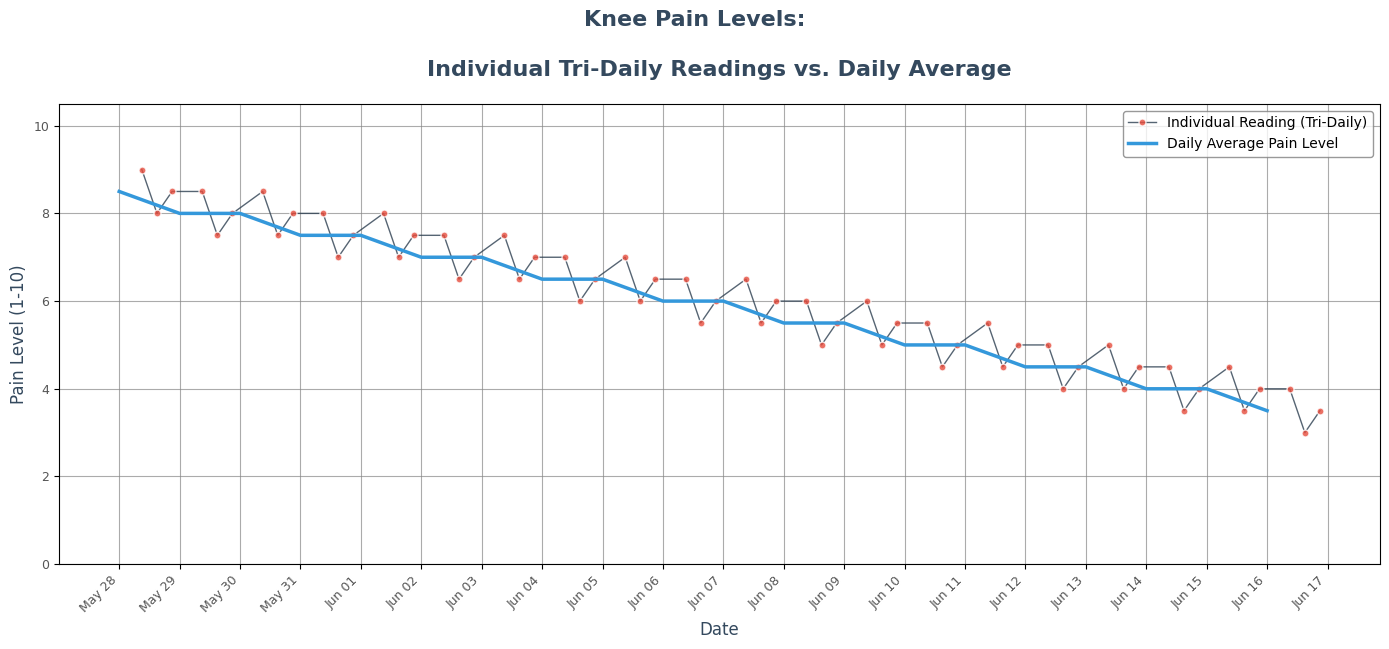

In [ ]:
# 2. TIME SERIES PLOT (Version 4: Simplified & Readable X-axis)

plt.figure(figsize=(14, 7))

# --- 1. Plot Individual Tri-Daily Pain Levels ---
# 'df.index' still contains my tri-daily timestamps, so all points are plotted.
plt.plot(df.index, df['Pain_Level'], color='#2c3e50', linewidth=1, alpha=0.8,
         marker='o', markersize=5, markerfacecolor='#e74c3c', markeredgecolor='white',
         label='Individual Reading (Tri-Daily)')


# --- 2. Calculate and Plot Daily Averages ---
daily_avg_pain = df.groupby(df.index.normalize())['Pain_Level'].mean()
plt.plot(daily_avg_pain.index, daily_avg_pain, color='#3498db', linewidth=2.5, linestyle='-',
         label='Daily Average Pain Level')


# --- Existing Plot Styling
plt.title('Individual Tri-Daily Readings vs. Daily Average', fontsize=16, fontweight='bold', color='#34495e', pad=20)
plt.suptitle('Knee Pain Levels:', fontsize=16, fontweight='bold', color='#34495e', y=0.95)

plt.xlabel('Date', fontsize=12, color='#34495e')
plt.ylabel('Pain Level (1-10)', fontsize=12, color='#34495e')

plt.grid(True, linestyle='-', alpha=0.7, color='#888888')
plt.gca().set_facecolor('white')


# --- X-axis formatting - The core changes for readability ---
# Only use Major Ticks for each day. The individual markers will show tri-daily points.
major_locator = mdates.DayLocator(interval=1) # One major tick per day
major_formatter = mdates.DateFormatter('%b %d') # Format for major ticks (e.g., 'May 29')

plt.gca().xaxis.set_major_locator(major_locator)
plt.gca().xaxis.set_major_formatter(major_formatter)

# Removed the minor_locator and minor_formatter.
# This significantly reduces clutter on the X-axis.

# Apply rotation and other styling directly using plt.xticks (which applies to major ticks by default)
plt.xticks(fontsize=9, rotation=45, ha='right', color='#555')
plt.yticks(fontsize=9, color='#555')

plt.ylim(0, 10.5)

plt.legend(fontsize=10, loc='upper right', frameon=True, edgecolor='gray')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



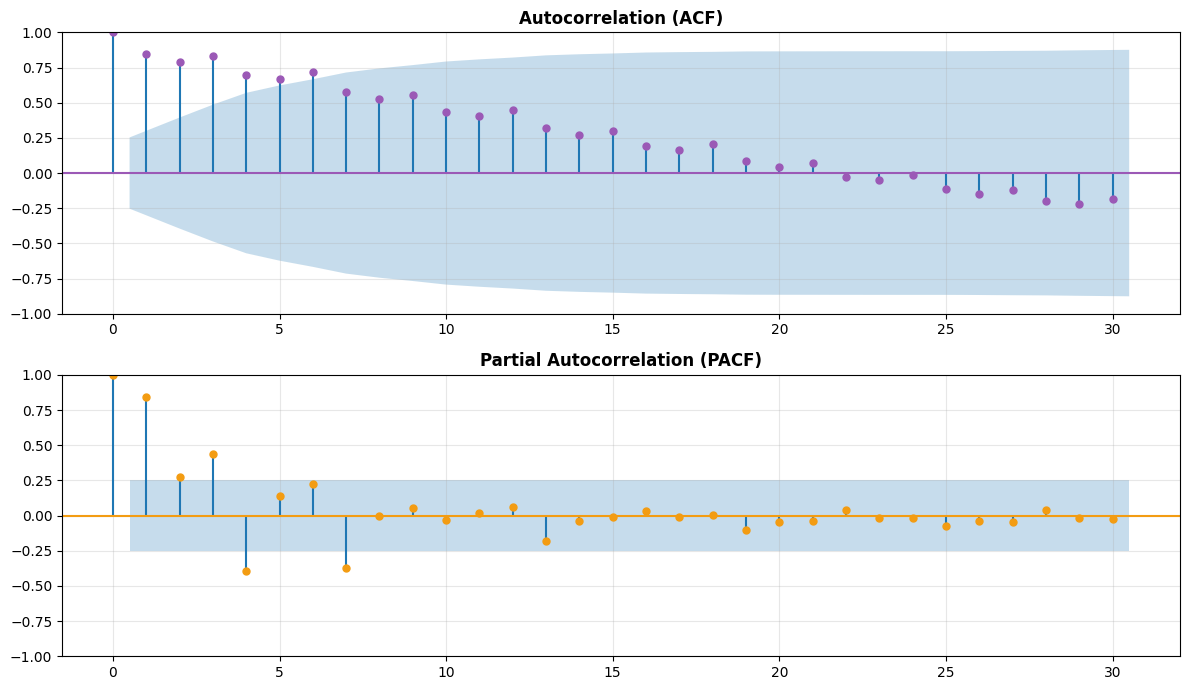

In [ ]:
# 4. AUTOCORRELATION ANALYSIS

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

plot_acf(df['Pain_Level'], lags=30, ax=ax1, color='#9b59b6')
ax1.set_title('Autocorrelation (ACF)', fontweight='bold')
ax1.grid(alpha=0.3)

plot_pacf(df['Pain_Level'], lags=30, ax=ax2, color='#f39c12')
ax2.set_title('Partial Autocorrelation (PACF)', fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

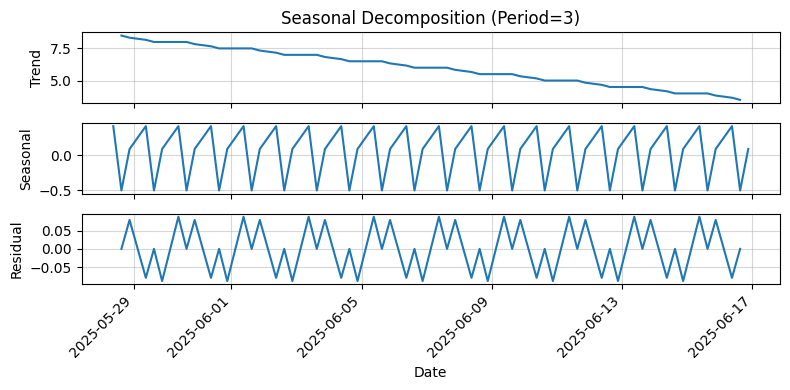

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates

# Assuming 'df' is your DataFrame with a DatetimeIndex and 'Pain_Level' column

# Option 1: Decompose based on a daily frequency (3 observations per day)
try:
    decomposition_daily = seasonal_decompose(df['Pain_Level'], model='additive', period=3)

    # Plot the decomposition (excluding observed)
    fig, axes = plt.subplots(3, 1, figsize=(8, 4), sharex=True) # Reduced to 3 subplots

    axes[0].plot(decomposition_daily.trend)
    axes[0].set_ylabel('Trend')
    axes[0].set_title('Seasonal Decomposition (Period=3)')
    axes[0].grid(True, alpha=0.5)

    axes[1].plot(decomposition_daily.seasonal)
    axes[1].set_ylabel('Seasonal')
    axes[1].grid(True, alpha=0.5)

    axes[2].plot(decomposition_daily.resid)
    axes[2].set_ylabel('Residual')
    axes[2].grid(True, alpha=0.5)
    axes[2].set_xlabel('Date')

    # Format x-axis for better readability (using mdates as before)
    major_locator = mdates.AutoDateLocator()
    major_formatter = mdates.AutoDateFormatter(major_locator)
    for ax in axes:
        ax.xaxis.set_major_locator(major_locator)
        ax.xaxis.set_major_formatter(major_formatter)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

except ValueError as e:
    print(f"Could not perform decomposition with period=3. Ensure data covers multiple periods consistently. Error: {e}")
    print("Attempting decomposition with a longer period (e.g., weekly, period=21) if data allows...")

In [ ]:
# ======================
# 5. STATIONARITY TEST
# ======================
print("\n STATIONARITY TEST")

def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print(f'• ADF Statistic: {result[0]:.4f}')
    print(f'• p-value: {result[1]:.4f}')
    print('• Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')

    # Enhanced conclusion
    conclusion = "Stationary (reject null hypothesis)" if result[1] <= 0.05 \
        else "Non-Stationary (fail to reject null hypothesis)"
    print(f"\n• Conclusion: {conclusion}")
    print(f"• Interpretation: {'✅ Suitable for time series modeling' if result[1] <= 0.05 else '⚠️ Needs differencing/transformation'}")

adf_test(df['Pain_Level'])


 STATIONARITY TEST
• ADF Statistic: -0.0203
• p-value: 0.9568
• Critical Values:
   1%: -3.5715
   5%: -2.9226
   10%: -2.5993

• Conclusion: Non-Stationary (fail to reject null hypothesis)
• Interpretation: ⚠️ Needs differencing/transformation
